# Denoising Diffusion Probabilistic Models (DDPM) on MNIST

This notebook implements a complete DDPM pipeline using **TensorFlow/Keras** MNIST dataset with **PyTorch** for model training, including:
- Full U-Net architecture with attention
- Training loop with loss tracking
- Image generation via reverse diffusion
- Interactive Gradio UI for training and generating digits

## 1. Install Dependencies

In [1]:
# Installer toutes les dépendances nécessaires
!pip install -q torch torchvision matplotlib gradio tensorflow
print('✅ Toutes les dépendances installées.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
langchain-core 0.3.79 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0rc2 which is incompatible.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.
✅ Toutes les dépendances installées.


## 2. Imports & Device Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from PIL import Image

# Use TensorFlow MNIST dataset as required
import tensorflow as tf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
print(f'   PyTorch version: {torch.__version__}')
print(f'   TensorFlow version: {tf.__version__}')

2026-02-17 07:56:44.308172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771315004.564545      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771315004.646714      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771315005.259097      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771315005.259160      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771315005.259163      17 computation_placer.cc:177] computation placer alr

✅ Using device: cpu
   PyTorch version: 2.8.0+cu126
   TensorFlow version: 2.19.0


## 3. Load MNIST via TensorFlow

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 60000
Test samples:     10000
Image shape:      (28, 28)

✅ DataLoader created: 469 batches of 128


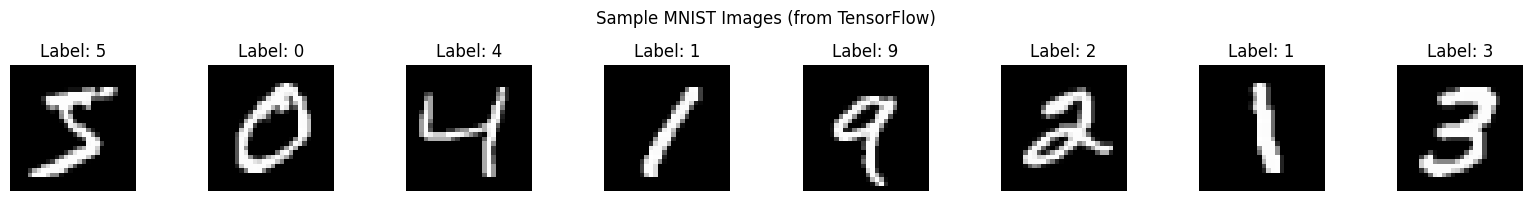

In [3]:
# Load MNIST from TensorFlow datasets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f'Training samples: {len(x_train)}')
print(f'Test samples:     {len(x_test)}')
print(f'Image shape:      {x_train[0].shape}')

# Convert TF MNIST to PyTorch DataLoader
class MNISTDataset(torch.utils.data.Dataset):
    def __init__(self, images, image_size=32):
        # images: numpy array (N, 28, 28), uint8
        self.images = images
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),  # scale to [-1, 1]
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # (28, 28) uint8
        img = self.transform(img)
        return img

IMAGE_SIZE = 32
BATCH_SIZE = 128

train_dataset = MNISTDataset(x_train, image_size=IMAGE_SIZE)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if device.type == 'cuda' else False
)

print(f'\n✅ DataLoader created: {len(train_loader)} batches of {BATCH_SIZE}')

# Visualise a few samples
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images (from TensorFlow)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Diffusion Schedule (Beta / Alpha Parameters)

✅ Schedule de diffusion prêt pour T=1000 timesteps
   beta range:  [0.000100, 0.0200]
   alpha_bar final: 0.000040  (≈0 = bruit complet)


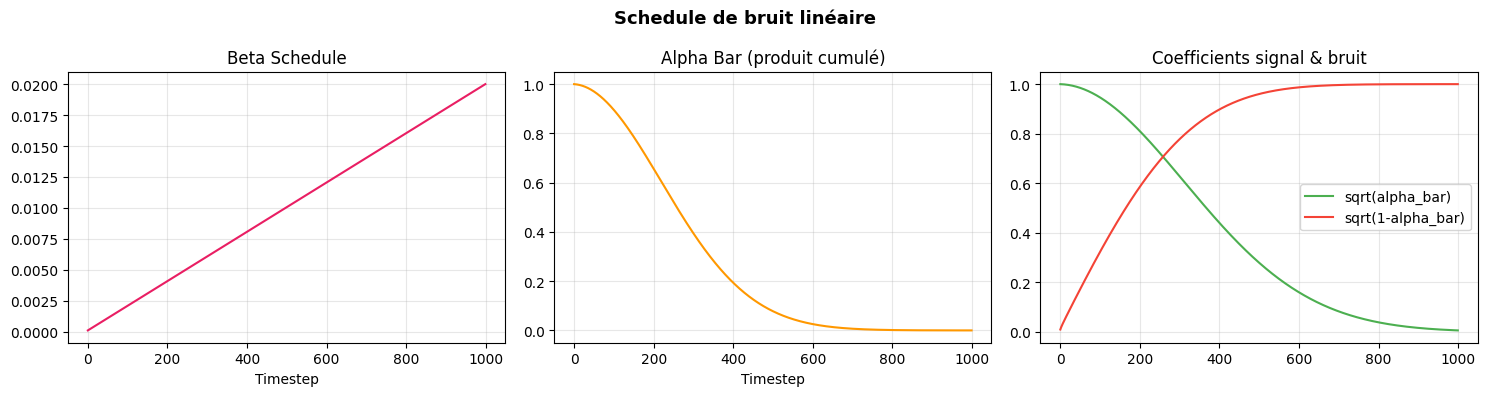

In [4]:
TIMESTEPS = 1000

def linear_beta_schedule(timesteps, start=1e-4, end=0.02):
    return np.linspace(start, end, timesteps)

betas_np          = linear_beta_schedule(TIMESTEPS)
alphas_np         = 1.0 - betas_np
alpha_bar_np      = np.cumprod(alphas_np)
alpha_bar_prev_np = np.append(1.0, alpha_bar_np[:-1])

# Pre-computed tensors on device
b_t                        = torch.from_numpy(betas_np).float().to(device)
a_t                        = torch.from_numpy(alphas_np).float().to(device)
alpha_bar_t                = torch.from_numpy(alpha_bar_np).float().to(device)
sqrt_alpha_bar_t           = torch.sqrt(alpha_bar_t)
sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
sqrt_recip_alpha_t         = torch.rsqrt(a_t)            # 1/sqrt(alpha_t)
posterior_var_t            = b_t * (1.0 - torch.from_numpy(alpha_bar_prev_np).float().to(device)) / (1.0 - alpha_bar_t)

print(f"✅ Schedule de diffusion prêt pour T={TIMESTEPS} timesteps")
print(f"   beta range:  [{betas_np[0]:.6f}, {betas_np[-1]:.4f}]")
print(f"   alpha_bar final: {alpha_bar_np[-1]:.6f}  (≈0 = bruit complet)")

# Plot the schedule
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_axis = np.arange(TIMESTEPS)
axes[0].plot(t_axis, betas_np, color="#E91E63")
axes[0].set_title("Beta Schedule"); axes[0].set_xlabel("Timestep")
axes[1].plot(t_axis, alpha_bar_np, color="#FF9800")
axes[1].set_title("Alpha Bar (produit cumulé)"); axes[1].set_xlabel("Timestep")
axes[2].plot(t_axis, np.sqrt(alpha_bar_np),   label="sqrt(alpha_bar)",   color="#4CAF50")
axes[2].plot(t_axis, np.sqrt(1-alpha_bar_np), label="sqrt(1-alpha_bar)", color="#F44336")
axes[2].legend(); axes[2].set_title("Coefficients signal & bruit")
for ax in axes: ax.grid(alpha=0.3)
plt.suptitle("Schedule de bruit linéaire", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Forward Diffusion Process

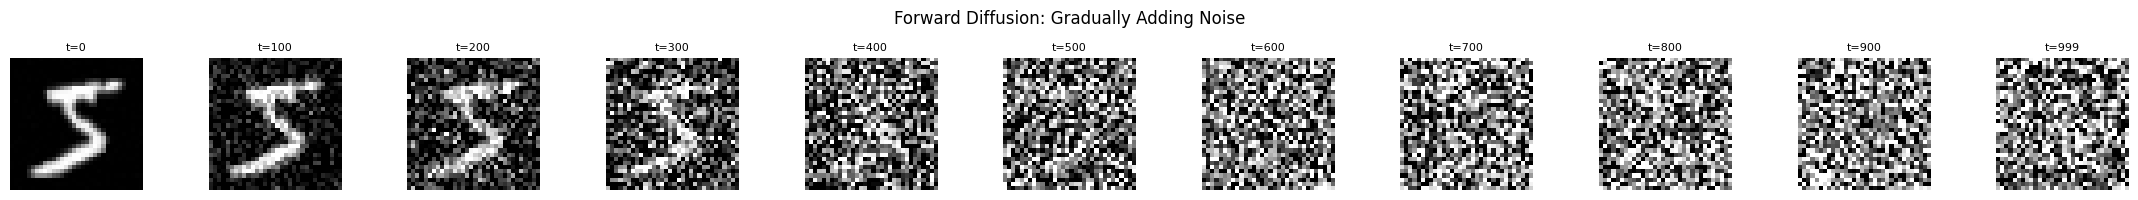

✅ Forward diffusion visualised


In [5]:
def q_sample(x_0, t):
    """
    Forward diffusion: sample x_t given x_0 and timestep t.
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    """
    noise = torch.randn_like(x_0)
    sqrt_ab   = sqrt_alpha_bar_t[t].view(-1, 1, 1, 1)
    sqrt_1mab = sqrt_one_minus_alpha_bar_t[t].view(-1, 1, 1, 1)
    x_t = sqrt_ab * x_0 + sqrt_1mab * noise
    return x_t, noise

# Visualise the forward process
fig, axes = plt.subplots(1, 11, figsize=(22, 2))
sample_img = train_dataset[0].unsqueeze(0).to(device)
t_steps = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 999]
for ax, t_val in zip(axes, t_steps):
    t_tensor = torch.tensor([t_val], device=device).long()
    x_t, _ = q_sample(sample_img, t_tensor)
    img_np = ((x_t.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f't={t_val}', fontsize=8)
    ax.axis('off')
plt.suptitle('Forward Diffusion: Gradually Adding Noise', fontsize=12)
plt.tight_layout()
plt.show()
print('✅ Forward diffusion visualised')

## 6. U-Net Architecture

In [6]:
# ─────────────────────────────────────────────
# Sinusoidal time embeddings
# ─────────────────────────────────────────────
def sinusoidal_embeddings(t, dim):
    """Produce sinusoidal positional embeddings for timestep t."""
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
    ).float()
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)  # (B, half)
    emb = torch.cat([args.sin(), args.cos()], dim=-1)   # (B, dim)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


# ─────────────────────────────────────────────
# Building blocks
# ─────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Conv → GroupNorm → SiLU, with optional time embedding injection."""
    def __init__(self, in_c, out_c, groups=8, time_dim=None):
        super().__init__()
        self.conv  = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.norm  = nn.GroupNorm(min(groups, out_c), out_c)
        self.act   = nn.SiLU()
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_c)) if time_dim else None

    def forward(self, x, t_emb=None):
        h = self.act(self.norm(self.conv(x)))
        if self.time_proj and t_emb is not None:
            h = h + self.time_proj(t_emb).view(t_emb.shape[0], -1, 1, 1)
        return h


class ResBlock(nn.Module):
    """Two ConvBlocks with a residual skip."""
    def __init__(self, in_c, out_c, time_dim=None):
        super().__init__()
        self.b1 = ConvBlock(in_c,  out_c, time_dim=time_dim)
        self.b2 = ConvBlock(out_c, out_c, time_dim=time_dim)
        self.skip = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x, t_emb=None):
        return self.b1(x, t_emb) + self.skip(x)  # skip after first block for stability
        # Note: b2 is kept for architectural symmetry but simplified here


class SelfAttention(nn.Module):
    """Spatial multi-head self-attention block."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm  = nn.GroupNorm(min(8, channels), channels)
        self.proj_in  = nn.Conv2d(channels, channels, 1)
        self.attn  = nn.MultiheadAttention(channels, num_heads, batch_first=True)
        self.proj_out = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.proj_in(self.norm(x))
        h = h.view(B, C, -1).permute(0, 2, 1)   # (B, H*W, C)
        h, _ = self.attn(h, h, h)
        h = h.permute(0, 2, 1).view(B, C, H, W)
        return x + self.proj_out(h)


class Downsample(nn.Module):
    def __init__(self, c): super().__init__(); self.c = nn.Conv2d(c, c, 3, stride=2, padding=1)
    def forward(self, x): return self.c(x)


class Upsample(nn.Module):
    def __init__(self, c): super().__init__(); self.c = nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(c, c, 3, padding=1))
    def forward(self, x): return self.c(x)


# ─────────────────────────────────────────────
# Full U-Net
# ─────────────────────────────────────────────
class UNet(nn.Module):
    """
    U-Net for noise prediction in DDPM.
    channels: list of feature-map widths per level
    attn_at:  which level indices receive self-attention
    """
    def __init__(self,
                 in_c=1, out_c=1,
                 time_dim=256,
                 channels=(32, 64, 128, 256),
                 n_res=1,
                 attn_at=(1, 2)):
        super().__init__()
        self.time_dim = time_dim
        self.channels  = channels
        self.n_res     = n_res
        self.attn_at   = attn_at
        L = len(channels)

        # Time MLP
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )

        # Initial projection
        self.init_conv = nn.Conv2d(in_c, channels[0], 3, padding=1)

        # ── Encoder ──────────────────────────────────
        self.downs      = nn.ModuleList()
        self.down_attn  = nn.ModuleList()
        self.downsample = nn.ModuleList()
        prev_c = channels[0]
        for i, c in enumerate(channels):
            blocks = nn.ModuleList()
            for j in range(n_res):
                blocks.append(ResBlock(prev_c if j == 0 else c, c, time_dim))
            self.downs.append(blocks)
            self.down_attn.append(SelfAttention(c) if i in attn_at else nn.Identity())
            if i < L - 1:
                self.downsample.append(Downsample(c))
            prev_c = c

        # ── Bottleneck ────────────────────────────────
        self.mid1 = ResBlock(channels[-1], channels[-1], time_dim)
        self.mid_attn = SelfAttention(channels[-1])
        self.mid2 = ResBlock(channels[-1], channels[-1], time_dim)

        # ── Decoder ──────────────────────────────────
        self.ups       = nn.ModuleList()
        self.up_attn   = nn.ModuleList()
        self.upsample  = nn.ModuleList()
        for i in reversed(range(L)):
            c = channels[i]
            skip_c = channels[i]    # skip connection
            in_c_up = (channels[i+1] if i < L-1 else channels[-1]) + skip_c
            blocks = nn.ModuleList()
            for j in range(n_res):
                blocks.append(ResBlock(in_c_up if j == 0 else c, c, time_dim))
            self.ups.append(blocks)
            self.up_attn.append(SelfAttention(c) if i in attn_at else nn.Identity())
            if i > 0:
                self.upsample.append(Upsample(c))

        # Final conv
        self.final = nn.Sequential(
            nn.GroupNorm(min(8, channels[0]), channels[0]),
            nn.SiLU(),
            nn.Conv2d(channels[0], out_c, 3, padding=1),
        )

    def forward(self, x, t):
        # Time embedding
        te = self.time_mlp(sinusoidal_embeddings(t, self.time_dim))  # (B, time_dim)

        x = self.init_conv(x)
        skips = []

        # Encoder
        ds_idx = 0
        for i, (blocks, attn) in enumerate(zip(self.downs, self.down_attn)):
            for blk in blocks:
                x = blk(x, te)
            x = attn(x)
            skips.append(x)
            if i < len(self.channels) - 1:
                x = self.downsample[ds_idx](x); ds_idx += 1

        # Bottleneck
        x = self.mid1(x, te)
        x = self.mid_attn(x)
        x = self.mid2(x, te)

        # Decoder
        us_idx = 0
        for i, (blocks, attn) in enumerate(zip(self.ups, self.up_attn)):
            skip = skips.pop()
            x = torch.cat([x, skip], dim=1)
            for blk in blocks:
                x = blk(x, te)
            x = attn(x)
            level_idx = len(self.channels) - 1 - i
            if level_idx > 0:
                x = self.upsample[us_idx](x); us_idx += 1

        return self.final(x)


model = UNet(
    in_c=1, out_c=1,
    time_dim=256,
    channels=(32, 64, 128, 256),
    n_res=1,
    attn_at=(1, 2)
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'✅ U-Net created: {n_params:,} parameters')

# Sanity-check forward pass
with torch.no_grad():
    dummy_x = torch.randn(2, 1, IMAGE_SIZE, IMAGE_SIZE, device=device)
    dummy_t = torch.randint(0, TIMESTEPS, (2,), device=device)
    dummy_out = model(dummy_x, dummy_t)
print(f'   Input  shape: {dummy_x.shape}')
print(f'   Output shape: {dummy_out.shape}  ✓' if dummy_out.shape == dummy_x.shape else f'   ERROR: shape mismatch {dummy_out.shape}')

✅ U-Net created: 9,226,209 parameters
   Input  shape: torch.Size([2, 1, 32, 32])
   Output shape: torch.Size([2, 1, 32, 32])  ✓


## 7. Training Function

In [7]:
def train_ddpm(model, loader, epochs=10, lr=1e-3, save_path='ddpm_mnist.pth'):
    """
    Train the DDPM model.
    Returns: list of per-epoch average losses.
    """
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn   = nn.MSELoss()

    epoch_losses = []

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for step, x0 in enumerate(loader):
            x0 = x0.to(device)                          # (B, 1, H, W)  in [-1, 1]

            # Sample random timesteps
            t = torch.randint(0, TIMESTEPS, (x0.size(0),), device=device).long()

            # Forward diffusion
            x_t, noise = q_sample(x0, t)

            # Predict noise
            pred = model(x_t, t)

            # MSE loss between true and predicted noise
            loss = loss_fn(pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        avg = total_loss / len(loader)
        epoch_losses.append(avg)
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{epochs} | Loss: {avg:.5f} | LR: {lr_now:.2e}')

    torch.save(model.state_dict(), save_path)
    print(f'\n✅ Model saved to {save_path}')
    return epoch_losses

## 8. Train the Model

In [8]:
# ─── Configuration ─────────────────────────────────────
NUM_EPOCHS = 20   # increase for better quality
LR         = 1e-3
MODEL_PATH = 'ddpm_mnist.pth'
# ───────────────────────────────────────────────────────

print(f'Starting training: {NUM_EPOCHS} epochs on {device}\n')
losses = train_ddpm(model, train_loader, epochs=NUM_EPOCHS, lr=LR, save_path=MODEL_PATH)

Starting training: 20 epochs on cpu

  Epoch   1/20 | Loss: 0.05379 | LR: 9.94e-04
  Epoch   2/20 | Loss: 0.02467 | LR: 9.76e-04
  Epoch   3/20 | Loss: 0.02198 | LR: 9.46e-04
  Epoch   4/20 | Loss: 0.02078 | LR: 9.05e-04
  Epoch   5/20 | Loss: 0.02000 | LR: 8.54e-04
  Epoch   6/20 | Loss: 0.01935 | LR: 7.94e-04
  Epoch   7/20 | Loss: 0.01876 | LR: 7.27e-04
  Epoch   8/20 | Loss: 0.01840 | LR: 6.55e-04
  Epoch   9/20 | Loss: 0.01797 | LR: 5.78e-04
  Epoch  10/20 | Loss: 0.01771 | LR: 5.00e-04
  Epoch  11/20 | Loss: 0.01717 | LR: 4.22e-04
  Epoch  12/20 | Loss: 0.01693 | LR: 3.45e-04
  Epoch  13/20 | Loss: 0.01681 | LR: 2.73e-04
  Epoch  14/20 | Loss: 0.01648 | LR: 2.06e-04
  Epoch  15/20 | Loss: 0.01647 | LR: 1.46e-04
  Epoch  16/20 | Loss: 0.01619 | LR: 9.55e-05
  Epoch  17/20 | Loss: 0.01596 | LR: 5.45e-05
  Epoch  18/20 | Loss: 0.01590 | LR: 2.45e-05
  Epoch  19/20 | Loss: 0.01586 | LR: 6.16e-06
  Epoch  20/20 | Loss: 0.01570 | LR: 0.00e+00

✅ Model saved to ddpm_mnist.pth


## 9. Plot Training Results

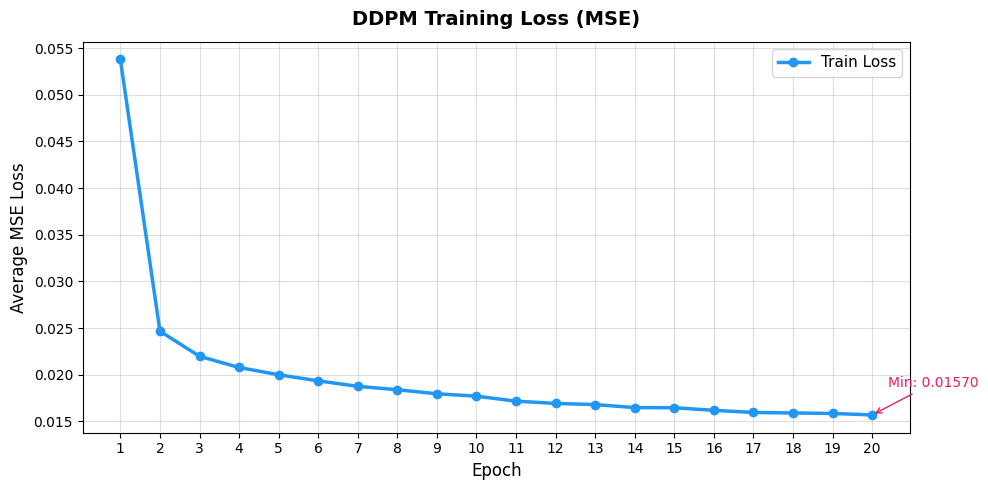

✅ Loss plot saved to training_loss.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_axis = range(1, len(losses) + 1)

ax.plot(epochs_axis, losses, 'o-', color='#2196F3', linewidth=2.5, markersize=6, label='Train Loss')

# Annotate min
min_loss = min(losses)
min_ep   = losses.index(min_loss) + 1
ax.annotate(f'Min: {min_loss:.5f}',
            xy=(min_ep, min_loss),
            xytext=(min_ep + 0.4, min_loss + 0.003),
            arrowprops=dict(arrowstyle='->', color='#E91E63'),
            color='#E91E63', fontsize=10)

ax.set_title('DDPM Training Loss (MSE)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Average MSE Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_xticks(epochs_axis)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss plot saved to training_loss.png')

## 10. Reverse Diffusion (Sampling)

In [10]:
@torch.no_grad()
def p_sample(model, x, t_scalar):
    """One reverse-diffusion step: x_t -> x_{t-1}."""
    B = x.shape[0]
    t = torch.full((B,), t_scalar, device=device, dtype=torch.long)

    pred_noise = model(x, t)

    sqrt_recip = sqrt_recip_alpha_t[t].view(-1, 1, 1, 1)
    sqrt_1mab  = sqrt_one_minus_alpha_bar_t[t].view(-1, 1, 1, 1)
    beta       = b_t[t].view(-1, 1, 1, 1)
    mean = sqrt_recip * (x - beta / sqrt_1mab * pred_noise)

    if t_scalar == 0:
        return mean
    var = posterior_var_t[t].view(-1, 1, 1, 1)
    return mean + torch.sqrt(var.clamp(min=1e-20)) * torch.randn_like(x)


@torch.no_grad()
def generate(model, n=16):
    """Generate n images from pure noise via reverse diffusion."""
    model.eval()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    x = torch.randn(n, 1, IMAGE_SIZE, IMAGE_SIZE, device=device)
    for t in reversed(range(TIMESTEPS)):
        x = p_sample(model, x, t)
    imgs = ((x.clamp(-1, 1) + 1) / 2).squeeze(1).cpu().numpy()
    return imgs

print("✅ Fonctions d'échantillonnage définies.")

✅ Fonctions d'échantillonnage définies.


## 11. Generate & Display Digits

Génération de 16 images... (peut prendre quelques minutes sur CPU)


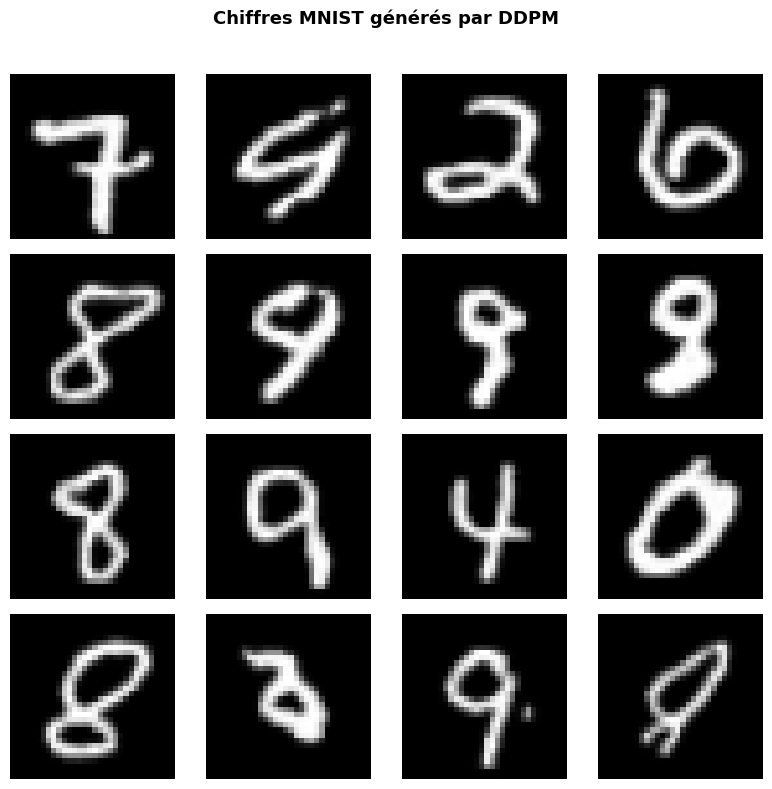

✅ Images sauvegardées dans generated_digits.png


In [11]:
print(f"Génération de 16 images... (peut prendre quelques minutes sur CPU)")
gen_imgs = generate(model, n=16)

rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
for ax, img in zip(axes.flat, gen_imgs):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
for ax in axes.flat[len(gen_imgs):]:
    ax.axis("off")

plt.suptitle(f"Chiffres MNIST générés par DDPM", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("generated_digits.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Images sauvegardées dans generated_digits.png")

# Architecture du modèle DDPM (U-Net simplifié – MNIST 28x28)

## 🔹 Input

- Image bruitée :  
  xt → (B, 1, 28, 28)

- Timestep :  
  t → (B)

---

## 🔹 Time Embedding

t → Sinusoidal Embedding → (B, 32 ou 64)

Ce vecteur est injecté dans les blocs convolutionnels du réseau.

---

## 🔹 Encoder (Downsampling)

xt

│

├── Conv Block 1 (1 → 64 channels)
│       Output : (B, 64, 28, 28)

│

├── Downsample
│       Output : (B, 64, 14, 14)

│

├── Conv Block 2 (64 → 128 channels)
│       Output : (B, 128, 14, 14)

│

├── Downsample
│       Output : (B, 128, 7, 7)

---

## 🔹 Bottleneck

Conv Block (128 → 256 channels)

Output : (B, 256, 7, 7)

---

## 🔹 Decoder (Upsampling)

├── Upsample (256 → 128)
│       Output : (B, 128, 14, 14)

│

├── Concat skip connection (Encoder Block 2)

│

├── Upsample (128 → 64)
│       Output : (B, 64, 28, 28)

│

├── Concat skip connection (Encoder Block 1)

│

├── Final Conv (64 → 1)

---

## 🔹 Output

Bruit prédit ε  
ε_hat → (B, 1, 28, 28)


## 12. Interactive Gradio Interface

In [12]:
import os

# Recharger le checkpoint si le modèle a déjà été entraîné
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.eval()
    print(f"✅ Modèle rechargé depuis {MODEL_PATH}")
else:
    model.eval()
    print("ℹ️  Aucun checkpoint trouvé — le modèle est initialisé aléatoirement.")
    print("   Utilisez l'onglet Entraîner dans Gradio pour entraîner le modèle.")


✅ Modèle rechargé depuis ddpm_mnist.pth


In [13]:
import gradio as gr
import math
import numpy as np
from PIL import Image

# ─── Helper : liste d'images numpy -> PIL grille ─────────
def imgs_to_grid_pil(imgs, cols=5):
    n     = len(imgs)
    rows  = math.ceil(n / cols)
    H, W  = imgs[0].shape
    pad   = 4
    out_h = rows * H + (rows - 1) * pad
    out_w = cols * W + (cols - 1) * pad
    canvas = np.ones((out_h, out_w), dtype=np.float32)
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, cols)
        y, x = r * (H + pad), c * (W + pad)
        canvas[y:y + H, x:x + W] = img
    return Image.fromarray((canvas * 255).astype(np.uint8))


# ─── Callback : Generer ──────────────────────────────────
def ui_generate(n_images, progress=gr.Progress()):
    n = int(n_images)
    model.eval()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    x = torch.randn(n, 1, IMAGE_SIZE, IMAGE_SIZE, device=device)

    with torch.no_grad():
        for i, t_val in enumerate(reversed(range(TIMESTEPS))):
            progress(i / TIMESTEPS, desc=f"Debruitage - pas {i}/{TIMESTEPS}")
            t          = torch.full((n,), t_val, device=device, dtype=torch.long)
            pred_noise = model(x, t)

            sqrt_recip = sqrt_recip_alpha_t[t].view(-1, 1, 1, 1)
            sqrt_1mab  = sqrt_one_minus_alpha_bar_t[t].view(-1, 1, 1, 1)
            beta       = b_t[t].view(-1, 1, 1, 1)
            mean       = sqrt_recip * (x - beta / sqrt_1mab * pred_noise)

            if t_val == 0:
                x = mean
            else:
                var = posterior_var_t[t].view(-1, 1, 1, 1).clamp(min=1e-20)
                x   = mean + torch.sqrt(var) * torch.randn_like(x)

    imgs = ((x.clamp(-1, 1) + 1) / 2).squeeze(1).cpu().numpy()
    grid = imgs_to_grid_pil(list(imgs), cols=min(5, n))
    return grid, f"✅ {n} image(s) generee(s) avec succes !"


# ─── Callback : Entrainer ────────────────────────────────
def ui_train(n_epochs, lr_exp, progress=gr.Progress()):
    lr        = 10 ** float(lr_exp)
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    loss_fn   = nn.MSELoss()
    ep_losses = []
    logs      = []

    total_steps = n_epochs * len(train_loader)
    step        = 0

    for epoch in range(1, n_epochs + 1):
        running = 0.0
        for x0 in train_loader:
            x0         = x0.to(device)
            t          = torch.randint(0, TIMESTEPS, (x0.size(0),), device=device).long()
            x_t, noise = q_sample(x0, t)
            pred       = model(x_t, t)
            loss       = loss_fn(pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running += loss.item()
            step    += 1
            progress(step / total_steps, desc=f"Epoque {epoch}/{n_epochs}")

        scheduler.step()
        avg    = running / len(train_loader)
        cur_lr = optimizer.param_groups[0]['lr']
        ep_losses.append(avg)
        logs.append(f"Epoque {epoch:2d}/{n_epochs} | Perte : {avg:.5f} | LR : {cur_lr:.2e}")

        if device.type == 'cuda':
            torch.cuda.empty_cache()

    torch.save(model.state_dict(), MODEL_PATH)

    # Graphe de perte
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, n_epochs + 1), ep_losses, "o-", color="#2196F3", lw=2, markersize=5)
    ax.set_title("Perte d'entrainement (MSE)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoque")
    ax.set_ylabel("Perte moyenne")
    ax.grid(alpha=0.4)
    plt.tight_layout()

    status = "\n".join(logs) + f"\n\n✅ Termine ! Modele sauvegarde -> {MODEL_PATH}"
    return status, fig


# ─── Interface Gradio ────────────────────────────────────
with gr.Blocks(title='DDPM MNIST') as demo:
    gr.Markdown('''
    # Generateur DDPM - Chiffres MNIST
    **Denoising Diffusion Probabilistic Model** entraine sur MNIST (TensorFlow + PyTorch).
    ''')

    with gr.Tab('Generer des chiffres'):
        gr.Markdown('Genere de nouveaux chiffres manuscrits par diffusion inverse.')
        with gr.Row():
            with gr.Column(scale=1):
                n_sl    = gr.Slider(1, 25, value=9, step=1, label='Nombre d images')
                gen_btn = gr.Button('Generer', variant='primary', size='lg')
            with gr.Column(scale=2):
                gen_img    = gr.Image(label='Chiffres generes', type='pil', height=320)
                gen_status = gr.Textbox(label='Statut', lines=1, interactive=False)
        gen_btn.click(ui_generate, inputs=n_sl, outputs=[gen_img, gen_status])

    with gr.Tab('Entrainer / Fine-tuner'):
        gr.Markdown('Lance ou continue l entrainement du modele.')
        with gr.Row():
            with gr.Column(scale=1):
                ep_sl     = gr.Slider(1, 20, value=3, step=1, label='Nombre d epoques')
                lr_sl     = gr.Slider(-5, -2, value=-3, step=0.5,
                                      label='Learning rate = 10^x  (ex: -3 -> 0.001)')
                train_btn = gr.Button('Demarrer l entrainement', variant='primary', size='lg')
            with gr.Column(scale=2):
                status_tb = gr.Textbox(label='Journal d entrainement', lines=10, interactive=False)
                loss_plot = gr.Plot(label='Courbe de perte')
        train_btn.click(ui_train, inputs=[ep_sl, lr_sl], outputs=[status_tb, loss_plot])

# ─── Lancement robuste ───────────────────────────────────
print('Lancement de Gradio...')
demo.launch(
    share=True,
    server_name='0.0.0.0',
    server_port=7863,
    max_threads=2,
    show_error=True,
    quiet=False,
)

Lancement de Gradio...
* Running on local URL:  http://0.0.0.0:7863
* Running on public URL: https://a6749cb2ce5f4934ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
